# Support Vector Machine- Supervised Multiclass Task

This pipeline includes data preprocessing, specific for this model, followed by the training and the evaluation of the classifier. The options in terms of data preprocessing and hyperparameters are the same as in the previous Binary Classification task.

**Results and Discussion:**

- Again, alancing standardization of the data had a big impact in the results. So we kept both. 

- A study similar to the previous one was performed in terms of features. This time, the best results were obtained with the set of features B. 

- We performed experiments with the rest of the hyperparameters, similar to the ones in the previous section and present below the model being trained with the set of hyperparameters that obtained the best results.

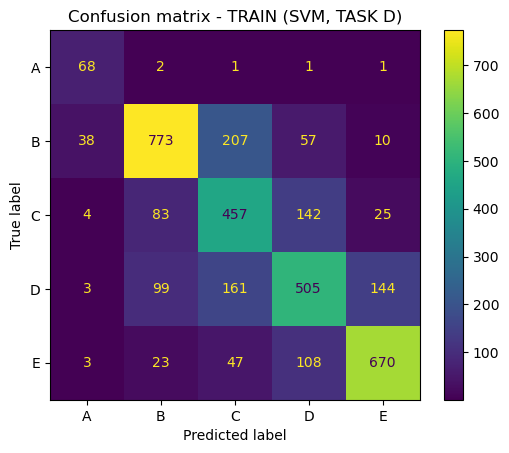

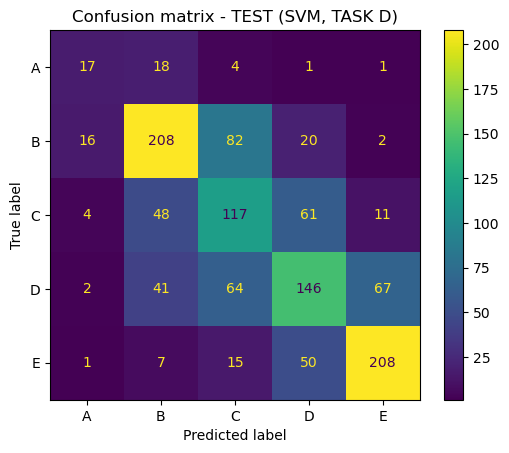

TRAIN classification report (TASK D):
              precision    recall  f1-score   support

           A       0.59      0.93      0.72        73
           B       0.79      0.71      0.75      1085
           C       0.52      0.64      0.58       711
           D       0.62      0.55      0.59       912
           E       0.79      0.79      0.79       851

    accuracy                           0.68      3632
   macro avg       0.66      0.73      0.68      3632
weighted avg       0.69      0.68      0.68      3632

TEST classification report (TASK D):
              precision    recall  f1-score   support

           A       0.42      0.41      0.42        41
           B       0.65      0.63      0.64       328
           C       0.41      0.49      0.45       241
           D       0.53      0.46      0.49       320
           E       0.72      0.74      0.73       281

    accuracy                           0.57      1211
   macro avg       0.55      0.55      0.55      1211
we

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score
)
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import roc_auc_score

STANDARDIZE = True
BALANCE = True
USE_NON_LINEAR = True  # Set to True for LinearSVC, False for Kernelized SVC (RBF/Poly)

# Hyperparameters
C = 1.0                 # Regularization
KERNEL_TYPE = 'rbf'     # 'rbf', 'poly', or 'sigmoid'
GAMMA_VALUE = 'scale'   # 'scale' or 'auto'
MAX_ITER = 5000         # Iterations for convergence


df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

numeric_features = [
     "RECENT_AVG_GIFT_AMT", 
    "LAST_GIFT_AMT", 
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", 
    "LIFETIME_MAX_GIFT_AMT", 
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", 
    "MONTHS_SINCE_FIRST_GIFT", 
    "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", 
    "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", 
    "RECENT_RESPONSE_COUNT", 
    "WEALTH_RATING"
]

categorical_features = [
    "URBANICITY", 
    "SES", "DONOR_GENDER", 
    "RECENCY_STATUS_96NK"
]

# Filtering for donors only and creating the target variable
df_D = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_D["DONATION_TYPE"] = df_D["TARGET_D"].apply(donation_type)

# Keeping only target and selected predictors
df_D = df_D[["DONATION_TYPE"] + numeric_features + categorical_features].copy()

# Treating missing values BEFORE the split
for col in numeric_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    med = df_D[col].median()
    df_D[col] = df_D[col].fillna(med)

for col in categorical_features:
    df_D[col] = df_D[col].fillna("Unknown")

# One-hot encoding
df_D_encoded = pd.get_dummies(df_D, columns=categorical_features, drop_first=True)

X_D_full = df_D_encoded.drop("DONATION_TYPE", axis=1)
y_D_full = df_D_encoded["DONATION_TYPE"]

# Split
X_train_svm_D, X_test_svm_D, y_train_svm_D, y_test_svm_D = train_test_split(
    X_D_full, y_D_full, random_state=42
)

# Model Selection Logic
class_weight = "balanced" if BALANCE else None

if USE_NON_LINEAR is False:
    # Linear model
    model_step = ("svm", LinearSVC(C=C, class_weight=class_weight, max_iter=MAX_ITER, random_state=42))
else:
    # Kernelized model (RBF/Poly)
    model_step = ("svm", SVC(kernel=KERNEL_TYPE, C=C, gamma=GAMMA_VALUE, 
                             class_weight=class_weight, probability=True, random_state=42))

steps = []
if STANDARDIZE:
    steps.append(("scaler", StandardScaler()))
steps.append(model_step)

svm_model_D = Pipeline(steps)
svm_model_D.fit(X_train_svm_D, y_train_svm_D)

# --- FINAL OUTPUT STATISTICS (MLP STYLE) ---

# Predictions
y_D_train_pred = svm_model_D.predict(X_train_svm_D)
y_D_test_pred  = svm_model_D.predict(X_test_svm_D)

# TRAIN confusion matrix
cm_train = confusion_matrix(y_train_svm_D, y_D_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=svm_model_D.named_steps["svm"].classes_)
disp_train.plot()
plt.title(f"Confusion matrix - TRAIN (SVM, TASK D)")
plt.show()

# TEST confusion matrix
cm_test = confusion_matrix(y_test_svm_D, y_D_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=svm_model_D.named_steps["svm"].classes_)
disp_test.plot()
plt.title(f"Confusion matrix - TEST (SVM, TASK D)")
plt.show()

# Classification reports
print("TRAIN classification report (TASK D):")
print(classification_report(y_train_svm_D, y_D_train_pred))

print("TEST classification report (TASK D):")
print(classification_report(y_test_svm_D, y_D_test_pred))

# AUC calculation for Multiclass (One-vs-Rest)
if USE_NON_LINEAR is False:
    # Use decision function for LinearSVC
    scores_raw = svm_model_D.decision_function(X_test_svm_D)
    # Apply Softmax to convert raw distances to probabilities (sums to 1.0)
    exp_scores = np.exp(scores_raw)
    scores_test_D = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
else:
    # Use predict_proba for SVC (requires probability=True)
    scores_test_D = svm_model_D.predict_proba(X_test_svm_D)

all_classes = svm_model_D.named_steps["svm"].classes_

auc_test_D = roc_auc_score(
    y_test_svm_D,
    scores_test_D,
    labels=all_classes,
    multi_class="ovr",
    average="macro"
)

print("TEST macro AUC (TASK D) =", auc_test_D)